## Rozwiązanie klasyczne

In [1]:
a_param_str = "01101"

a_param = int(a_param_str, 2)
num_bits = len(a_param_str)
def f_classical(x):
    return (x & a_param).bit_count() % 2

In [2]:
a_param_found = 0
x_mask = 1
for i in range(num_bits):
    print(f"{x_mask:0{num_bits}b} -> {f_classical(x_mask)}")
    a_param_found |= (f_classical(x_mask) << i)
    x_mask <<= 1
print(f"a_param -> {a_param_found:0{num_bits}b}")

00001 -> 1
00010 -> 0
00100 -> 1
01000 -> 1
10000 -> 0
a_param -> 01101


## Rozwiązanie kwantowe

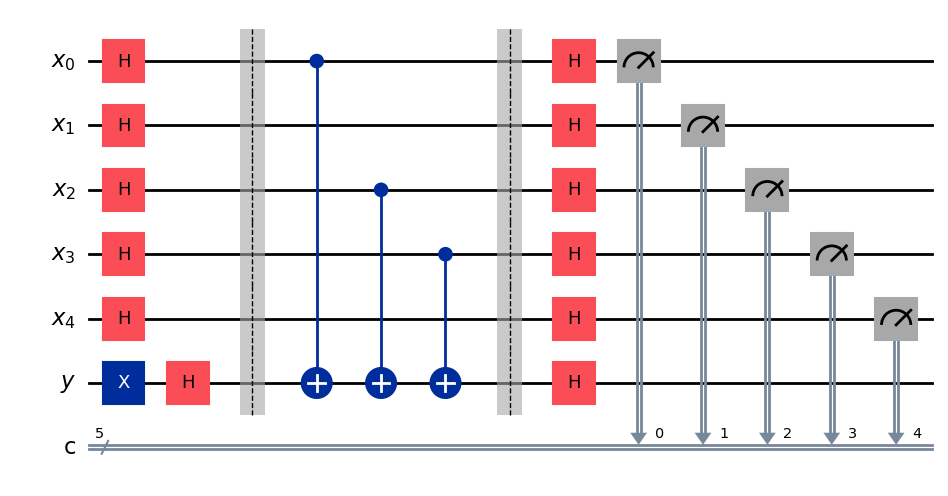

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

qc = QuantumCircuit(
    q_x := QuantumRegister(num_bits, "x"),
    q_y := QuantumRegister(1, "y"),
    c := ClassicalRegister(num_bits, "c"),
)

# Initialize output register y to |1>
qc.x(q_y)

# Apply Hadamard gates to x and y
qc.h(q_x)
qc.h(q_y)

qc.barrier()

# Implement the U_f gate
for i, bit in enumerate(reversed(a_param_str)):
    if bit == "1":
        qc.cx(q_x[i], q_y)

qc.barrier()

# Apply Hadamard gates again
qc.h(q_x)
qc.h(q_y)

# Measure (without y output register)
qc.measure(q_x, c)

display(qc.draw(output="mpl"))

{'01101': 1024}


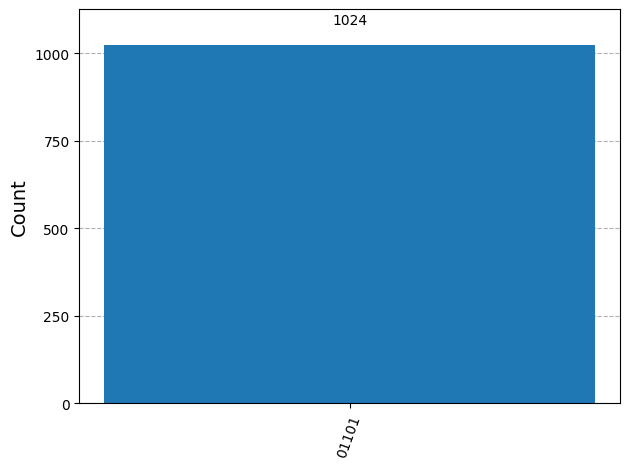

In [4]:
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2
from qiskit.visualization import plot_histogram

# Define backend
backend = AerSimulator()

# Transpile to backend
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
isa_qc = pm.run(qc)

# Display the transpiled circuit
# display(isa_qc.draw("mpl"))

# Run the job
sampler = SamplerV2(mode=backend)
job = sampler.run([isa_qc], shots=1024)
result = job.result()

# Extract counts data
counts = result[0].data.c.get_counts()
print(counts)

# Plot the counts in a histogram
plot_histogram(counts)

qiskit_runtime_service.__init__:WARNING:2026-04-21 02:38:06,070: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-21 02:38:06,071: Using instance: open-instance, plan: open


Selected backend: ibm_fez


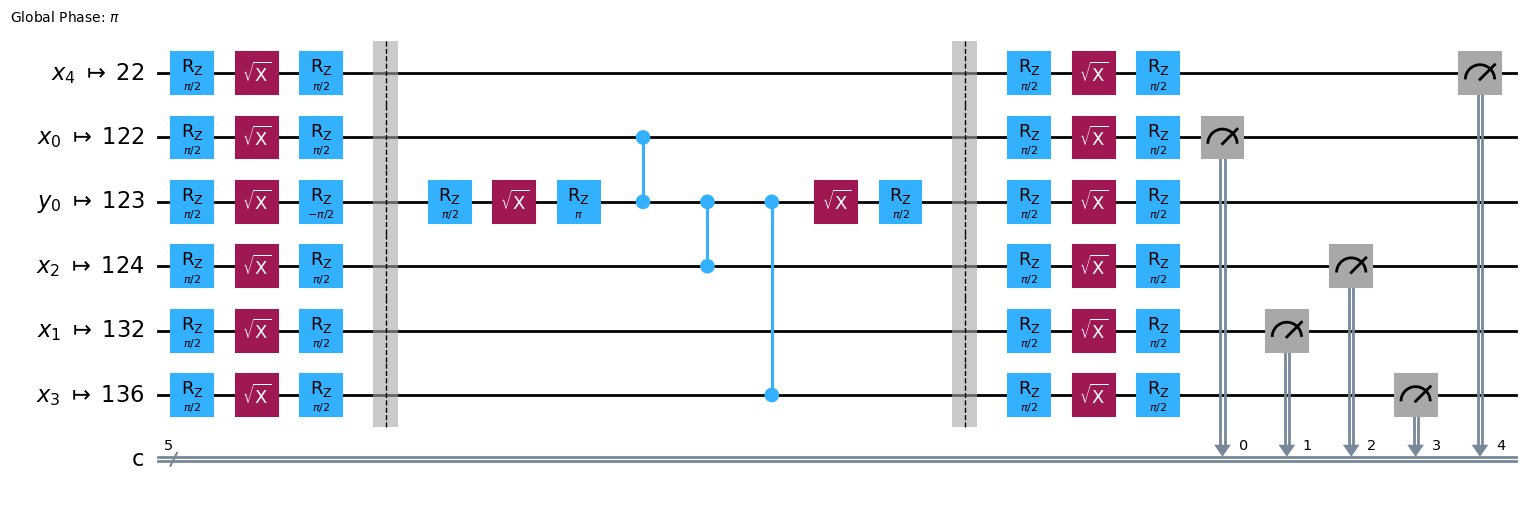

Job ID: d7jcb4hs7cos73ejnch0
Job status: DONE


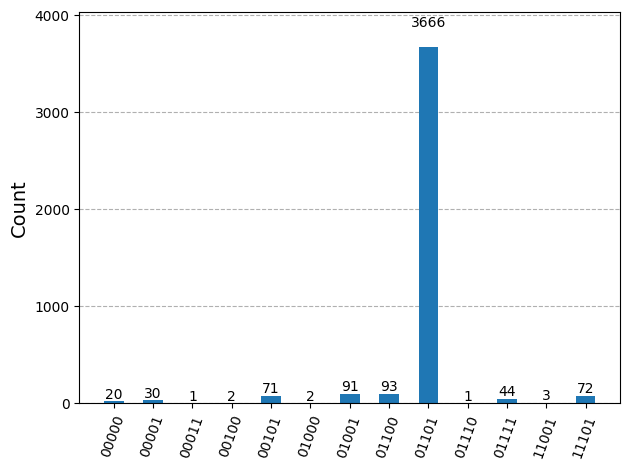

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

JOB_ID = "d7jcb4hs7cos73ejnch0"

service = QiskitRuntimeService()

backend = service.backend("ibm_fez")
print(f"Selected backend: {backend.name}")

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc)

display(isa_circuit.draw("mpl"))

if not JOB_ID:
    sampler = SamplerV2(backend)
    job = sampler.run([isa_circuit])
else:
    job = service.job(JOB_ID)

print(f"Job ID: {job.job_id()}")
print(f"Job status: {job.status()}")
result = job.result()

ibm_counts = result[0].data.c.get_counts()
display(plot_histogram(ibm_counts))